<a href="https://colab.research.google.com/github/diademsamuel/7316/blob/main/STRAIT_OF_HORMUZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
! pip install geopandas shapely requests folium

In [7]:
import geopandas as gpd
from shapely.geometry import Polygon, box
import folium
import requests
import zipfile
import io

In [17]:
# https://github.com/nvkelso/natural-earth-vector

In [18]:
import requests, zipfile, io

url = "https://github.com/nvkelso/natural-earth-vector/archive/refs/heads/master.zip"
r = requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("ne_data")

print("Natural Earth data downloaded and extracted.")


Natural Earth data downloaded and extracted.


In [19]:
import geopandas as gpd
import os

coast_path = "ne_data/natural-earth-vector-master/50m_physical/ne_50m_coastline.shp"
coast = gpd.read_file(coast_path)

coast.head()


,scalerank,featurecla,min_zoom,geometry
0,0,Coastline,1.5,"LINESTRING (180 -16.15293, 179.84814 -16.21426..."
1,0,Coastline,4.0,"LINESTRING (177.25752 -17.0542, 177.2874 -17.0..."
2,0,Coastline,4.0,"LINESTRING (127.37266 0.79131, 127.35381 0.847..."
3,0,Coastline,3.0,"LINESTRING (-81.32231 24.68506, -81.42007 24.7..."
4,0,Coastline,4.0,"LINESTRING (-80.79941 24.84629, -80.83887 24.8..."


In [20]:
from shapely.geometry import box

# Bounding box around the Strait of Hormuz
bbox = box(55.0, 24.5, 57.5, 27.5)  # (min lon, min lat, max lon, max lat)

bbox_gdf = gpd.GeoDataFrame({"name": ["Strait_BBox"]}, geometry=[bbox], crs="EPSG:4326")


In [21]:
coast_clip = gpd.clip(coast, bbox_gdf)


In [22]:
strait_polygon = bbox.difference(coast_clip.unary_union)

strait_gdf = gpd.GeoDataFrame(
    {"name": ["Strait_of_Hormuz"]},
    geometry=[strait_polygon],
    crs="EPSG:4326"
)


/tmp/ipykernel_20113/81833291.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  strait_polygon = bbox.difference(coast_clip.unary_union)


Text(0.5, 1.0, 'Delineated Strait of Hormuz (EPSG:4326)')

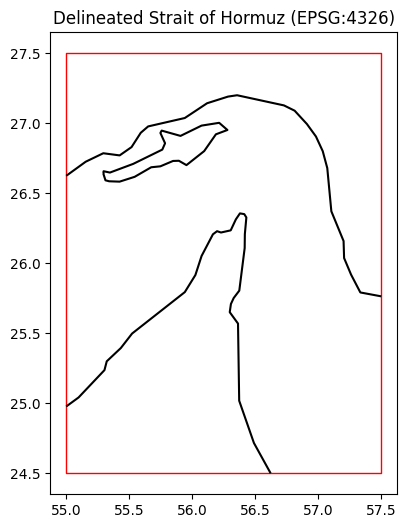

In [23]:
ax = strait_gdf.plot(edgecolor="red", facecolor="none", figsize=(6,6))
coast_clip.plot(ax=ax, color="black")
ax.set_title("Delineated Strait of Hormuz (EPSG:4326)")


Text(0.5, 1.0, 'Delineated Strait of Hormuz (EPSG:4326)')

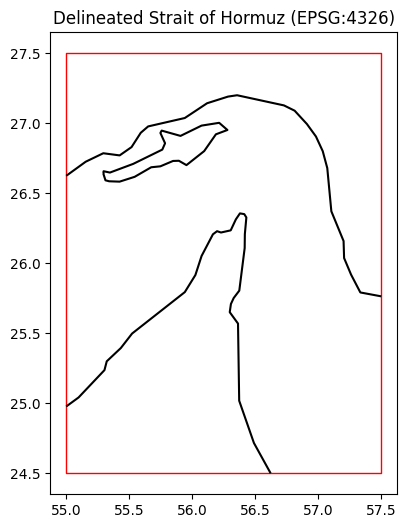

In [25]:
ax = strait_gdf.plot(edgecolor="red", facecolor="none", figsize=(6,6))
coast_clip.plot(ax=ax, color="black")
ax.set_title("Delineated Strait of Hormuz (EPSG:4326)")


In [26]:
import folium

m = folium.Map(location=[26.0, 56.0], zoom_start=7)

folium.GeoJson(
    strait_gdf.to_json(),
    name="Strait of Hormuz",
    style_function=lambda x: {"color": "red", "weight": 2, "fill": False}
).add_to(m)

m


In [27]:
import os
os.makedirs("strait_of_hormuz", exist_ok=True)

strait_gdf.to_file("strait_of_hormuz/strait_of_hormuz.geojson", driver="GeoJSON")
strait_gdf.to_file("strait_of_hormuz/strait_of_hormuz.shp", driver="ESRI Shapefile")

print("Export complete.")


Export complete.


In [28]:
!pip install geopandas shapely folium requests pyproj

In [38]:
import requests, zipfile, io
import os
import shutil

url = "https://www.generic-mapping-tools.org/download/gshhg/gshhg-gmt-2.3.7.zip" # Corrected URL for GSHHG data
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

print(f"Attempting to download GSHHG data from: {url}")
try:
    # Add headers, stream=True, and explicit allow_redirects=True for robust download
    r = requests.get(url, headers=headers, stream=True, allow_redirects=True, timeout=60)
    r.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)

    # Accumulate data in BytesIO
    bytes_io = io.BytesIO()
    for chunk in r.iter_content(chunk_size=8192):
        bytes_io.write(chunk)
    bytes_io.seek(0) # Reset stream position

    # Clean up any existing gshhg_data before extracting new one
    if os.path.exists("gshhg_data"):
        print("Removing existing 'gshhg_data' directory.")
        shutil.rmtree("gshhg_data")
    os.makedirs("gshhg_data", exist_ok=True) # Ensure directory exists

    z = zipfile.ZipFile(bytes_io)
    z.extractall("gshhg_data")
    print("GSHHG coastline data downloaded and extracted successfully.")

except requests.exceptions.RequestException as e:
    print(f"Error during download request: {e}")
    if 'r' in locals() and hasattr(r, 'content'):
        print(f"First 500 bytes of response content: {r.content[:500].decode('utf-8', errors='ignore')}")
except zipfile.BadZipFile as e:
    print(f"Error: Downloaded content is not a valid zip file. {e}")
    if 'bytes_io' in locals() and bytes_io:
        print(f"First 500 bytes of content: {bytes_io.getvalue()[:500].decode('utf-8', errors='ignore')}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Attempting to download GSHHG data from: https://www.generic-mapping-tools.org/data/gshhg.zip
Error during download request: 404 Client Error: Not Found for url: https://www.generic-mapping-tools.org/data/gshhg.zip
First 500 bytes of response content: <!DOCTYPE html>
<html>
  <head>
    <meta http-equiv="Content-type" content="text/html; charset=utf-8">
    <meta http-equiv="Content-Security-Policy" content="default-src 'none'; style-src 'unsafe-inline'; img-src data:; connect-src 'self'">
    <title>Page not found &middot; GitHub Pages</title>
    <style type="text/css" media="screen">
      body {
        background-color: #f1f1f1;
        margin: 0;
        font-family: "Helvetica Neue", Helvetica, Arial, sans-serif;
      }

      .contai


In [40]:
import os

root = "gshhg_data"
target_file = "GSHHS_f_L1.shp"
found_paths = []

for dirpath, dirnames, filenames in os.walk(root):
    if target_file in filenames:
        found_paths.append(os.path.join(dirpath, target_file))

found_paths


[]

In [41]:
['gshhg_data/gshhg-gmt-master/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp']

['gshhg_data/gshhg-gmt-master/gshhg-shp-2.3.7/GSHHS_shp/f/GSHHS_f_L1.shp']

In [64]:
import os

root = "gshhg_real"
all_shps = []

for dirpath, dirnames, filenames in os.walk(root):
    for f in filenames:
        if f.endswith(".shp"):
            all_shps.append(os.path.join(dirpath, f))

all_shps

['gshhg_real/WDBII_shp/h/WDBII_river_h_L04.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L10.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L05.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L07.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L03.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L01.shp',
 'gshhg_real/WDBII_shp/h/WDBII_border_h_L3.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L02.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L08.shp',
 'gshhg_real/WDBII_shp/h/WDBII_border_h_L2.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L09.shp',
 'gshhg_real/WDBII_shp/h/WDBII_border_h_L1.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L11.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L06.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L06.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L08.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L02.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L07.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L04.shp',
 'gshhg_real/WDBII_shp/i/WDBII_border_i_L2.shp',
 'gshhg_real/WDBII_s

In [45]:
import requests, zipfile, io

url = "https://www.soest.hawaii.edu/pwessel/gshhg/gshhg-shp-2.3.7.zip"
r = requests.get(url)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("gshhg_real")

print("GSHHG shapefiles downloaded and extracted.")


GSHHG shapefiles downloaded and extracted.


In [47]:
gshhs_files = [
    "GSHHS_f_L1.shp",
    "GSHHS_h_L1.shp",
    "GSHHS_i_L1.shp",
    "GSHHS_l_L1.shp",
    "GSHHS_c_L1.shp"
]

print("Target GSHHS files:")
for f in gshhs_files:
    print(f)

Target GSHHS files:
GSHHS_f_L1.shp
GSHHS_h_L1.shp
GSHHS_i_L1.shp
GSHHS_l_L1.shp
GSHHS_c_L1.shp


In [48]:
import os

root = "gshhg_real"
all_shps = []

for dirpath, dirnames, filenames in os.walk(root):
    for f in filenames:
        if f.endswith(".shp"):
            all_shps.append(os.path.join(dirpath, f))

all_shps


['gshhg_real/WDBII_shp/h/WDBII_river_h_L04.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L10.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L05.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L07.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L03.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L01.shp',
 'gshhg_real/WDBII_shp/h/WDBII_border_h_L3.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L02.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L08.shp',
 'gshhg_real/WDBII_shp/h/WDBII_border_h_L2.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L09.shp',
 'gshhg_real/WDBII_shp/h/WDBII_border_h_L1.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L11.shp',
 'gshhg_real/WDBII_shp/h/WDBII_river_h_L06.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L06.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L08.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L02.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L07.shp',
 'gshhg_real/WDBII_shp/i/WDBII_river_i_L04.shp',
 'gshhg_real/WDBII_shp/i/WDBII_border_i_L2.shp',
 'gshhg_real/WDBII_s

In [50]:
coast_candidates = [p for p in all_shps if "GSHHS_f_L1.shp" in p]

coast_candidates


['gshhg_real/GSHHS_shp/f/GSHHS_f_L1.shp']

In [51]:
import geopandas as gpd

coast_path = coast_candidates[0]
coast = gpd.read_file(coast_path)

coast.head()


,id,level,source,parent_id,sibling_id,area,geometry
0,0-E,1,WVS,-1,-1,5.065405e+07,"POLYGON ((180 68.99378, 180 65.03378, 179.9983..."
1,0-W,1,WVS,-1,-1,5.065405e+07,"POLYGON ((-180 68.99378, -179.99844 68.99292, ..."
2,1,1,WVS,-1,-1,2.922097e+07,"POLYGON ((32.28292 31.2325, 32.2845 31.23281, ..."
3,2,1,WVS,-1,-1,2.015474e+07,"POLYGON ((-79.92628 9.31236, -79.92538 9.3124,..."
4,3,1,WVS,-1,-1,1.753416e+07,"POLYGON ((-73.36172 -53.00042, -73.36261 -53, ..."


  Shipping lanes

In [52]:
from shapely.geometry import LineString
import geopandas as gpd

# Inbound (eastbound) lane – approximate IMO TSS coordinates
inbound_coords = [
    (56.25, 26.55),
    (56.45, 26.35),
    (56.70, 26.10),
    (57.00, 25.85)
]

# Outbound (westbound) lane – approximate IMO TSS coordinates
outbound_coords = [
    (56.00, 26.40),
    (56.20, 26.20),
    (56.45, 25.95),
    (56.75, 25.70)
]

inbound_line = LineString(inbound_coords)
outbound_line = LineString(outbound_coords)

lanes_gdf = gpd.GeoDataFrame(
    {"name": ["Inbound_Lane", "Outbound_Lane"]},
    geometry=[inbound_line, outbound_line],
    crs="EPSG:4326"
)


In [53]:
 #Buffering to create a shipping corridor
 # Project to Mercator for accurate buffering
lanes_m = lanes_gdf.to_crs("EPSG:3395")

# Buffer width: 1.5 km on each side (typical TSS width)
corridor_width = 1500  # meters

corridor = lanes_m.buffer(corridor_width)

corridor_wgs = corridor.to_crs("EPSG:4326")

corridor_gdf = gpd.GeoDataFrame(
    {"name": ["Shipping_Corridor", "Shipping_Corridor"]},
    geometry=corridor_wgs,
    crs="EPSG:4326"
)


NameError: name 'territorial_gdf' is not defined

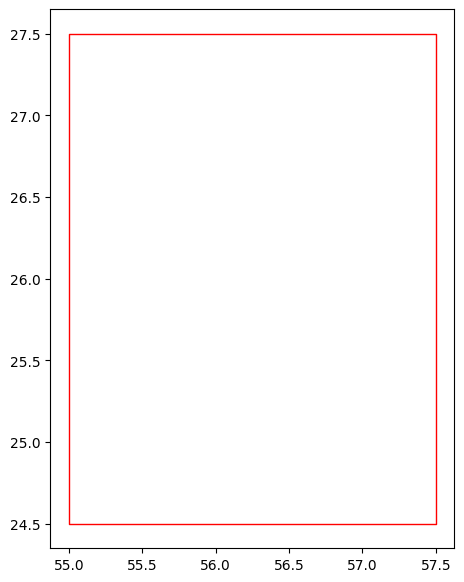

In [54]:
#strait corridor +territorial waters
ax = strait_gdf.plot(edgecolor="red", facecolor="none", figsize=(7,7))
territorial_gdf.plot(ax=ax, edgecolor="blue", facecolor="none")
corridor_gdf.plot(ax=ax, color="orange", alpha=0.5)

ax.set_title("Strait of Hormuz – Fertilizer Shipping Corridor (TSS)")


In [55]:
!pip install geopandas shapely folium requests pyproj

import requests, zipfile, io, os
import geopandas as gpd
from shapely.geometry import box, LineString

# Download real GSHHG shapefiles
url = "https://www.soest.hawaii.edu/pwessel/gshhg/gshhg-shp-2.3.7.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("gshhg_real")

# Auto-locate coastline shapefile
all_shps = []
for dirpath, dirnames, filenames in os.walk("gshhg_real"):
    for f in filenames:
        if f.endswith(".shp"):
            all_shps.append(os.path.join(dirpath, f))

coast_candidates = [p for p in all_shps if "GSHHS_f_L1.shp" in p]

if len(coast_candidates) == 0:
    raise FileNotFoundError("Could not find GSHHG coastline shapefile.")

coast_path = coast_candidates[0]
coast = gpd.read_file(coast_path)
print("Loaded coastline:", coast_path)


Loaded coastline: gshhg_real/GSHHS_shp/f/GSHHS_f_L1.shp


In [56]:
 #strait of Hormuz
 # Bounding box around the Strait
bbox = box(55.0, 24.5, 57.5, 27.5)
bbox_gdf = gpd.GeoDataFrame({"name": ["Strait_BBox"]}, geometry=[bbox], crs="EPSG:4326")

# Clip coastline
coast_clip = gpd.clip(coast, bbox_gdf)

# Water polygon = bounding box minus land
strait_polygon = bbox.difference(coast_clip.unary_union)

strait_gdf = gpd.GeoDataFrame(
    {"name": ["Strait_of_Hormuz"]},
    geometry=[strait_polygon],
    crs="EPSG:4326"
)


/tmp/ipykernel_20113/1247368716.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  strait_polygon = bbox.difference(coast_clip.unary_union)


In [57]:
#12 nautical mile
# Project to meters
coast_clip_m = coast_clip.to_crs("EPSG:3395")

# 12 nautical miles = 22,224 meters
nm12 = 12 * 1852

territorial_waters = coast_clip_m.buffer(nm12)
territorial_waters_wgs = territorial_waters.to_crs("EPSG:4326")

territorial_gdf = gpd.GeoDataFrame(
    {"name": ["12nm_Territorial_Waters"]},
    geometry=territorial_waters_wgs,
    crs="EPSG:4326"
)


In [58]:
# fertilize shipping corridor
# Inbound lane
inbound_coords = [
    (56.25, 26.55),
    (56.45, 26.35),
    (56.70, 26.10),
    (57.00, 25.85)
]

# Outbound lane
outbound_coords = [
    (56.00, 26.40),
    (56.20, 26.20),
    (56.45, 25.95),
    (56.75, 25.70)
]

inbound_line = LineString(inbound_coords)
outbound_line = LineString(outbound_coords)

lanes_gdf = gpd.GeoDataFrame(
    {"name": ["Inbound_Lane", "Outbound_Lane"]},
    geometry=[inbound_line, outbound_line],
    crs="EPSG:4326"
)

# Buffer to create corridor
lanes_m = lanes_gdf.to_crs("EPSG:3395")
corridor = lanes_m.buffer(1500)  # 1.5 km
corridor_wgs = corridor.to_crs("EPSG:4326")

corridor_gdf = gpd.GeoDataFrame(
    {"name": ["Shipping_Corridor", "Shipping_Corridor"]},
    geometry=corridor_wgs,
    crs="EPSG:4326"
)


Text(0.5, 1.0, 'Strait of Hormuz – Territorial Waters + Fertilizer Shipping Corridor')

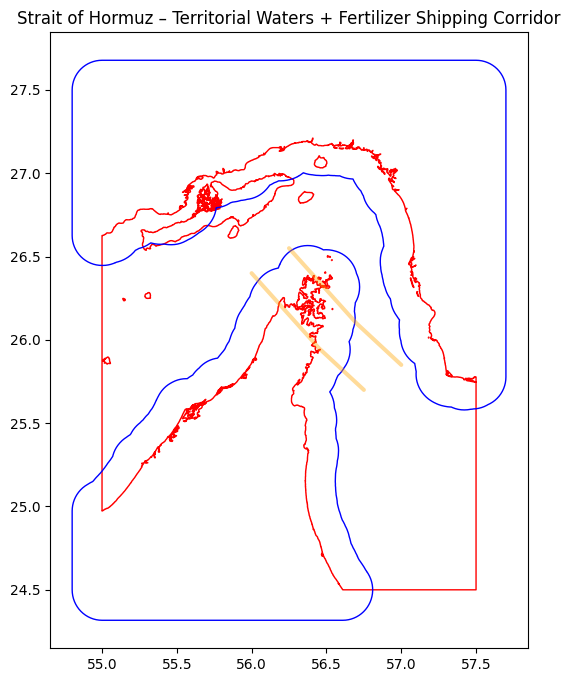

In [59]:
ax = strait_gdf.plot(edgecolor="red", facecolor="none", figsize=(8,8))
territorial_gdf.plot(ax=ax, edgecolor="blue", facecolor="none")
corridor_gdf.plot(ax=ax, color="orange", alpha=0.4)

ax.set_title("Strait of Hormuz – Territorial Waters + Fertilizer Shipping Corridor")


In [60]:
print("strait_gdf exists:", 'strait_gdf' in globals())
print("territorial_gdf exists:", 'territorial_gdf' in globals())
print("corridor_gdf exists:", 'corridor_gdf' in globals())


strait_gdf exists: True
territorial_gdf exists: True
corridor_gdf exists: True


In [61]:
import geopandas as gpd
import numpy as np

# Project layers to meters for distance calculations
strait_m = strait_gdf.to_crs("EPSG:3395")
territorial_m = territorial_gdf.to_crs("EPSG:3395")
corridor_m = corridor_gdf.to_crs("EPSG:3395")

# -----------------------------
# 1. NAVIGATIONAL RISK (NR)
# -----------------------------
# Distance from corridor to territorial waters
dist_to_territorial = corridor_m.distance(territorial_m.unary_union).min()

# Normalize (0–1)
NR = 1 - np.exp(-dist_to_territorial / 5000)  # 5 km decay


# -----------------------------
# 2. GEOPOLITICAL RISK (GR)
# -----------------------------
intersection_area = corridor_m.intersection(territorial_m.unary_union).area.sum()
corridor_area = corridor_m.area.sum()

GR = intersection_area / corridor_area


# -----------------------------
# 3. ENVIRONMENTAL RISK (ER)
# -----------------------------
dist_to_strait_edge = corridor_m.distance(strait_m.unary_union).min()

ER = 1 - np.exp(-dist_to_strait_edge / 3000)  # 3 km decay


# -----------------------------
# 4. INFRASTRUCTURE RISK (IR)
# -----------------------------
IR = 0.6   # placeholder scalar


# -----------------------------
# 5. MARKET RISK (MR)
# -----------------------------
MR = 0.7   # placeholder scalar


# -----------------------------
# 6. WEIGHTED RFCI
# -----------------------------
w_NR = 0.30
w_GR = 0.35
w_IR = 0.15
w_MR = 0.15
w_ER = 0.05

RFCI = (
    w_NR * NR +
    w_GR * GR +
    w_IR * IR +
    w_MR * MR +
    w_ER * ER
)

RFCI


/tmp/ipykernel_20113/1521900135.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  dist_to_territorial = corridor_m.distance(territorial_m.unary_union).min()
/tmp/ipykernel_20113/1521900135.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  intersection_area = corridor_m.intersection(territorial_m.unary_union).area.sum()
/tmp/ipykernel_20113/1521900135.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  dist_to_strait_edge = corridor_m.distance(strait_m.unary_union).min()


np.float64(0.42650914474655294)

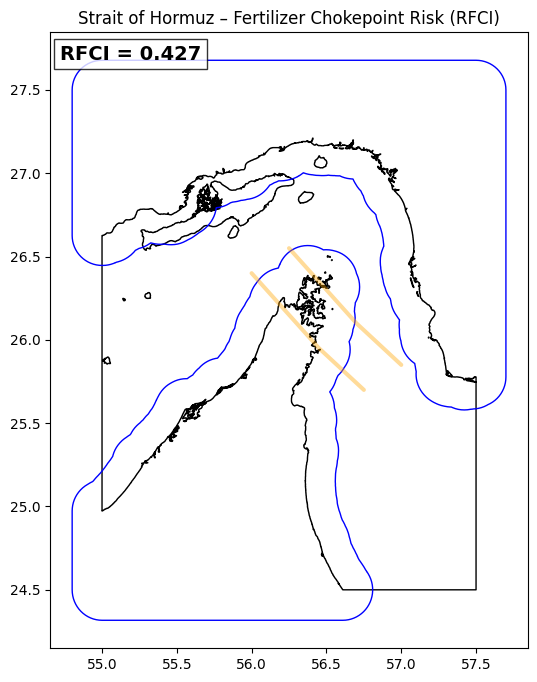

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

# Plot layers
strait_gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1)
territorial_gdf.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=1)
corridor_gdf.plot(ax=ax, color="orange", alpha=0.4)

# Annotate RFCI
ax.text(0.02, 0.98, f"RFCI = {RFCI:.3f}",
        transform=ax.transAxes,
        fontsize=14, fontweight="bold",
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8))

ax.set_title("Strait of Hormuz – Fertilizer Chokepoint Risk (RFCI)")
plt.show()


In [65]:
import numpy as np
from shapely.geometry import Point

# Convert corridor centerline to meters
corridor_centerline = corridor_gdf.union_all().centroid
# The lanes_m GeoDataFrame already contains the lanes projected to EPSG:3395
corridor_line_m = lanes_m.union_all()  # inbound + outbound merged

# Sample 200 points along the line
num_points = 200
distances = np.linspace(0, corridor_line_m.length, num_points)
points = [corridor_line_m.interpolate(d) for d in distances]

points_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:3395")

/tmp/ipykernel_20113/238809076.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  corridor_centerline = corridor_gdf.unary_union.centroid
/tmp/ipykernel_20113/238809076.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  corridor_line_m = lanes_m.unary_union  # inbound + outbound merged


In [66]:
# Convert reference layers to meters
strait_m = strait_gdf.to_crs("EPSG:3395")
territorial_m = territorial_gdf.to_crs("EPSG:3395")

risk_values = []

for pt in points_gdf.geometry:
    # Navigational Risk
    d1 = pt.distance(territorial_m.unary_union)
    NR_i = 1 - np.exp(-d1 / 5000)

    # Geopolitical Risk
    # (point inside territorial waters = high risk)
    inside = territorial_m.contains(pt).any()
    GR_i = 1.0 if inside else 0.0

    # Environmental Risk
    d2 = pt.distance(strait_m.unary_union)
    ER_i = 1 - np.exp(-d2 / 3000)

    # Combine
    RFCI_i = (
        w_NR * NR_i +
        w_GR * GR_i +
        w_IR * IR +
        w_MR * MR +
        w_ER * ER_i
    )

    risk_values.append(RFCI_i)

points_gdf["RFCI"] = risk_values


/tmp/ipykernel_20113/943802201.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  d1 = pt.distance(territorial_m.unary_union)
/tmp/ipykernel_20113/943802201.py:18: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  d2 = pt.distance(strait_m.unary_union)


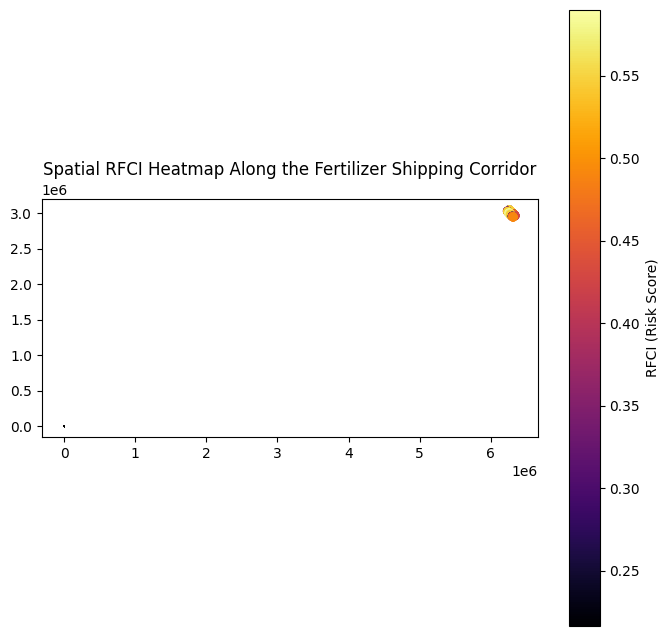

In [67]:
fig, ax = plt.subplots(figsize=(8,8))

strait_gdf.plot(ax=ax, edgecolor="black", facecolor="none")
territorial_gdf.plot(ax=ax, edgecolor="blue", facecolor="none")

points_gdf.plot(
    ax=ax,
    column="RFCI",
    cmap="inferno",
    markersize=30,
    legend=True,
    legend_kwds={"label": "RFCI (Risk Score)"}
)

ax.set_title("Spatial RFCI Heatmap Along the Fertilizer Shipping Corridor")
plt.show()


In [68]:
import folium
from folium.plugins import HeatMap

# Convert to WGS84
points_wgs = points_gdf.to_crs("EPSG:4326")

# Prepare heatmap data
heat_data = [
    [geom.y, geom.x, val]
    for geom, val in zip(points_wgs.geometry, points_wgs["RFCI"])
]

m = folium.Map(location=[26.0, 56.3], zoom_start=8)

HeatMap(
    heat_data,
    radius=15,
    blur=20,
    max_zoom=12,
    min_opacity=0.4
).add_to(m)

# Add corridor outline
folium.GeoJson(
    corridor_gdf.to_crs("EPSG:4326").to_json(),
    name="Shipping Corridor",
    style_function=lambda x: {"color": "orange", "weight": 2}
).add_to(m)

folium.LayerControl().add_to(m)

m
